# Exploratory Data Analysis — Phishing Websites


## Step 1: Load dataset from phishing.db (either from local data/ folder or download from URL)

In [11]:
import os
import sqlite3
import pandas as pd
import urllib.request

DB_URL = "https://techassessment.blob.core.windows.net/aiap22-assessment-data/phishing.db"
LOCAL_PATH = "data/phishing.db"

# If the DB file doesn't exist locally, attempt to download it.
if not os.path.exists(LOCAL_PATH):
    try:
        os.makedirs("data", exist_ok=True)
        print(f"Downloading database from {DB_URL} to {LOCAL_PATH} ...")
        urllib.request.urlretrieve(DB_URL, LOCAL_PATH)
        print("Download complete.")
    except Exception as e:
        print("Could not download the DB automatically.\nPlease place `phishing.db` in the `data/` folder and re-run this cell.\nError:", e)

# Connect and read tables
if os.path.exists(LOCAL_PATH):
    conn = sqlite3.connect(LOCAL_PATH)
    table_name = "phishing_data"
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    print('Data loaded. Shape:', df.shape)
    display(df.head())
else:
    print('phishing.db not found. Place it under data/phishing.db and re-run this cell.')

Data loaded. Shape: (10500, 16)


,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
0,0,NaN,9965,0,0,2,1,48,172,170,1,1,Fashion,DreamHost,98,0
1,1,769.0,9507,0,0,0,4,25,55,78,1,1,Fashion,AWS,31,1
2,2,720.0,2550,0,0,0,2,-31,94,13,0,1,Education,Google Cloud,26,1
3,3,198.0,869,0,0,0,0,0,0,2,0,0,Unknown,DreamHost,2,1
4,4,972.0,2807,0,0,0,2,6,83,51,0,1,Education,GoDaddy,43,1


The dataset contains 10,500 rows and 16 columns, the majority of which are numeric features. These columns represent various structural and behavioral characteristics of websites, and will be examined further to understand their distributions, data quality, and relevance to phishing detection.

## Step 2: High-level overview

**Purpose:** Understand dataset size, column names, data types, the number of missing values, and the descriptive statistics of the dataset.

In [12]:
print("Basic overview: dataset size, column names, data types, missing values")
print(df.info())

Basic overview: dataset size, column names, data types, missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10500 non-null  int64  
 1   LineOfCode         8145 non-null   float64
 2   LargestLineLength  10500 non-null  int64  
 3   NoOfURLRedirect    10500 non-null  int64  
 4   NoOfSelfRedirect   10500 non-null  int64  
 5   NoOfPopup          10500 non-null  int64  
 6   NoOfiFrame         10500 non-null  int64  
 7   NoOfImage          10500 non-null  int64  
 8   NoOfSelfRef        10500 non-null  int64  
 9   NoOfExternalRef    10500 non-null  int64  
 10  Robots             10500 non-null  int64  
 11  IsResponsive       10500 non-null  int64  
 12  Industry           10500 non-null  object 
 13  HostingProvider    10500 non-null  object 
 14  DomainAgeMonths    10500 non-null  int64  
 15 

Most columns have complete data, with the exception of `LineOfCode`, which has approximately 22% missing values. The majority of features represent numerical counts extracted from each website, such as `redirects`, `pop-ups`, `iFrames`, `images`, and `reference links`.

Two binary features (`Robots`, `IsResponsive`) indicate specific website characteristics, while `Industry` and `HostingProvider` are categorical attributes describing the site's business domain and hosting service. 

The target variable, `label`, identifies whether a website is `phishing` (0) or `legitimate` (1).

In [13]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())

print("\nDescriptive statistics for categorical columns:")
print(df.describe(include='object'))


Descriptive statistics for numerical columns:
         Unnamed: 0     LineOfCode  LargestLineLength  NoOfURLRedirect  \
count  10500.000000    8145.000000       1.050000e+04     10500.000000   
mean    5249.500000    1376.952363       1.119796e+04         0.136762   
std     3031.233247    5751.557001       9.416898e+04         0.343612   
min        0.000000       2.000000       2.200000e+01         0.000000   
25%     2624.750000      88.000000       1.807500e+02         0.000000   
50%     5249.500000     620.000000       1.087500e+03         0.000000   
75%     7874.250000    1452.000000       8.047000e+03         0.000000   
max    10499.000000  418650.000000       4.336498e+06         1.000000   

       NoOfSelfRedirect     NoOfPopup    NoOfiFrame     NoOfImage  \
count      10500.000000  10500.000000  10500.000000  1.050000e+04   
mean           0.038476      0.227524      1.668381  3.252675e+02   
std            0.192352      5.700292      5.016302  3.089686e+04   
min       

### Interpretation of the Statistics

**Numerical Features:**

*   **LineOfCode**: The number of lines of code varies significantly, from 2 to 418,650, with a median of 620. This wide range suggests potential outliers or highly complex pages. The mean (1207.18) is higher than the median, indicating a right-skewed distribution.
*   **LargestLineLength**: Similar to `LineOfCode`, this feature shows a vast range (22 to 4.3 million), suggesting highly varying content lengths. The mean (11197.96) is much larger than the median (1087.5), confirming a heavily right-skewed distribution, likely due to a few extremely long lines.
*   **NoOfURLRedirect, NoOfSelfRedirect, NoOfPopup**: The majority of entries for these features are 0, as indicated by their 25th, 50th, and 75th percentiles being 0. This suggests that URL redirects, self-redirects, and popups are not very common in the dataset, or occur in a small subset of the data. However, the max values (1 and 564 respectively) show that they do occur.
*   **NoOfiFrame**: The median is 0, but the maximum is 131, indicating that while most pages might not use iframes, some use them extensively.
*   **NoOfImage**: This feature has a minimum value of -35, which is unusual and suggests potential data quality issues, as the number of images cannot be negative. The values range up to 3.16 million, indicating a wide spread. The median is 5, but the mean is 325.27, again suggesting a skewed distribution with potential outliers.
*   **NoOfSelfRef & NoOfExternalRef**: These features also show wide ranges (0-26596 and 0-12353 respectively) and right-skewed distributions, with means (68.54 and 51.15) significantly higher than medians (12 and 10), indicating that most pages have few references, but some have a very large number.
*   **Robots & IsResponsive**: These are binary features (0 or 1). For `Robots`, 26.3% of entries are 1 (mean=0.26). For `IsResponsive`, 62.4% are 1 (mean=0.62), indicating that a majority of sites are responsive.
*   **DomainAgeMonths**: The domain age ranges from 0 to 120 months (10 years). The mean (33.17) and median (24) are relatively close, indicating a somewhat more symmetrical distribution compared to the previous count-based features, but still slightly right-skewed. This suggests a mix of new and established domains.
*   **label**: This is the target variable, indicating 0 or 1. The mean (0.55) suggests that approximately 55% of the entries are phishing (label=1), indicating a slight imbalance but generally well-distributed classes.

**Categorical Features:**

*   **Industry**: There are 11 unique industry categories. 'eCommerce' is the most frequent (top) industry, appearing 2521 times (freq).
*   **HostingProvider**: There are 13 unique hosting providers. 'Unknown Provider' is the most frequent, appearing 1177 times. This category might need further investigation or careful handling during model building, as it represents a significant portion of the data.

## Step 3: Data cleaning and preprocessing

**Purpose:** Identify and address any missing values within the dataset. Analyze the data types of each column and convert them if necessary (e.g., converting object types to numerical or categorical where appropriate) ensuring data quality and prepares the dataset for accurate statistical analysis and visualization.

In [14]:
# 1. Remove the 'Unnamed: 0' column
df = df.drop('Unnamed: 0', axis=1)
print("Dropped 'Unnamed: 0' column.")

# 2. Address missing values in 'LineOfCode' with the median
median_line_of_code = df['LineOfCode'].median()
df['LineOfCode'] = df['LineOfCode'].fillna(median_line_of_code)
print(f"Imputed missing 'LineOfCode' values with median: {median_line_of_code}")

# 3. Address the data quality issue in 'NoOfImage': replace negative values with 0
df['NoOfImage_cleaned'] = df['NoOfImage'].apply(lambda x: max(x, 0))
print("Replaced negative values in 'NoOfImage' with 0.")

# 4. Convert 'Industry' and 'HostingProvider' to 'category' type
df['Industry'] = df['Industry'].astype('category')
df['HostingProvider'] = df['HostingProvider'].astype('category')
print("Converted 'Industry' and 'HostingProvider' to category type.")

print("\nDataFrame Info after handling missing values and data types:")
df.info()

Dropped 'Unnamed: 0' column.
Imputed missing 'LineOfCode' values with median: 620.0
Replaced negative values in 'NoOfImage' with 0.
Converted 'Industry' and 'HostingProvider' to category type.

DataFrame Info after handling missing values and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   LineOfCode         10500 non-null  float64 
 1   LargestLineLength  10500 non-null  int64   
 2   NoOfURLRedirect    10500 non-null  int64   
 3   NoOfSelfRedirect   10500 non-null  int64   
 4   NoOfPopup          10500 non-null  int64   
 5   NoOfiFrame         10500 non-null  int64   
 6   NoOfImage          10500 non-null  int64   
 7   NoOfSelfRef        10500 non-null  int64   
 8   NoOfExternalRef    10500 non-null  int64   
 9   Robots             10500 non-null  int64   
 10  IsResponsive       10500 non-null  int64   

## Step 4: Visualize Feature Distributions

**Purpose:** Create a series of clear, meaningful, and understandable visualizations (e.g., histograms, box plots, bar charts) to illustrate the distribution of key individual features. These visualizations will help in identifying patterns, skewness, and potential outliers, providing visual context to the statistical summaries.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

### Check Features' Distributions 

Generating histograms for numerical features...


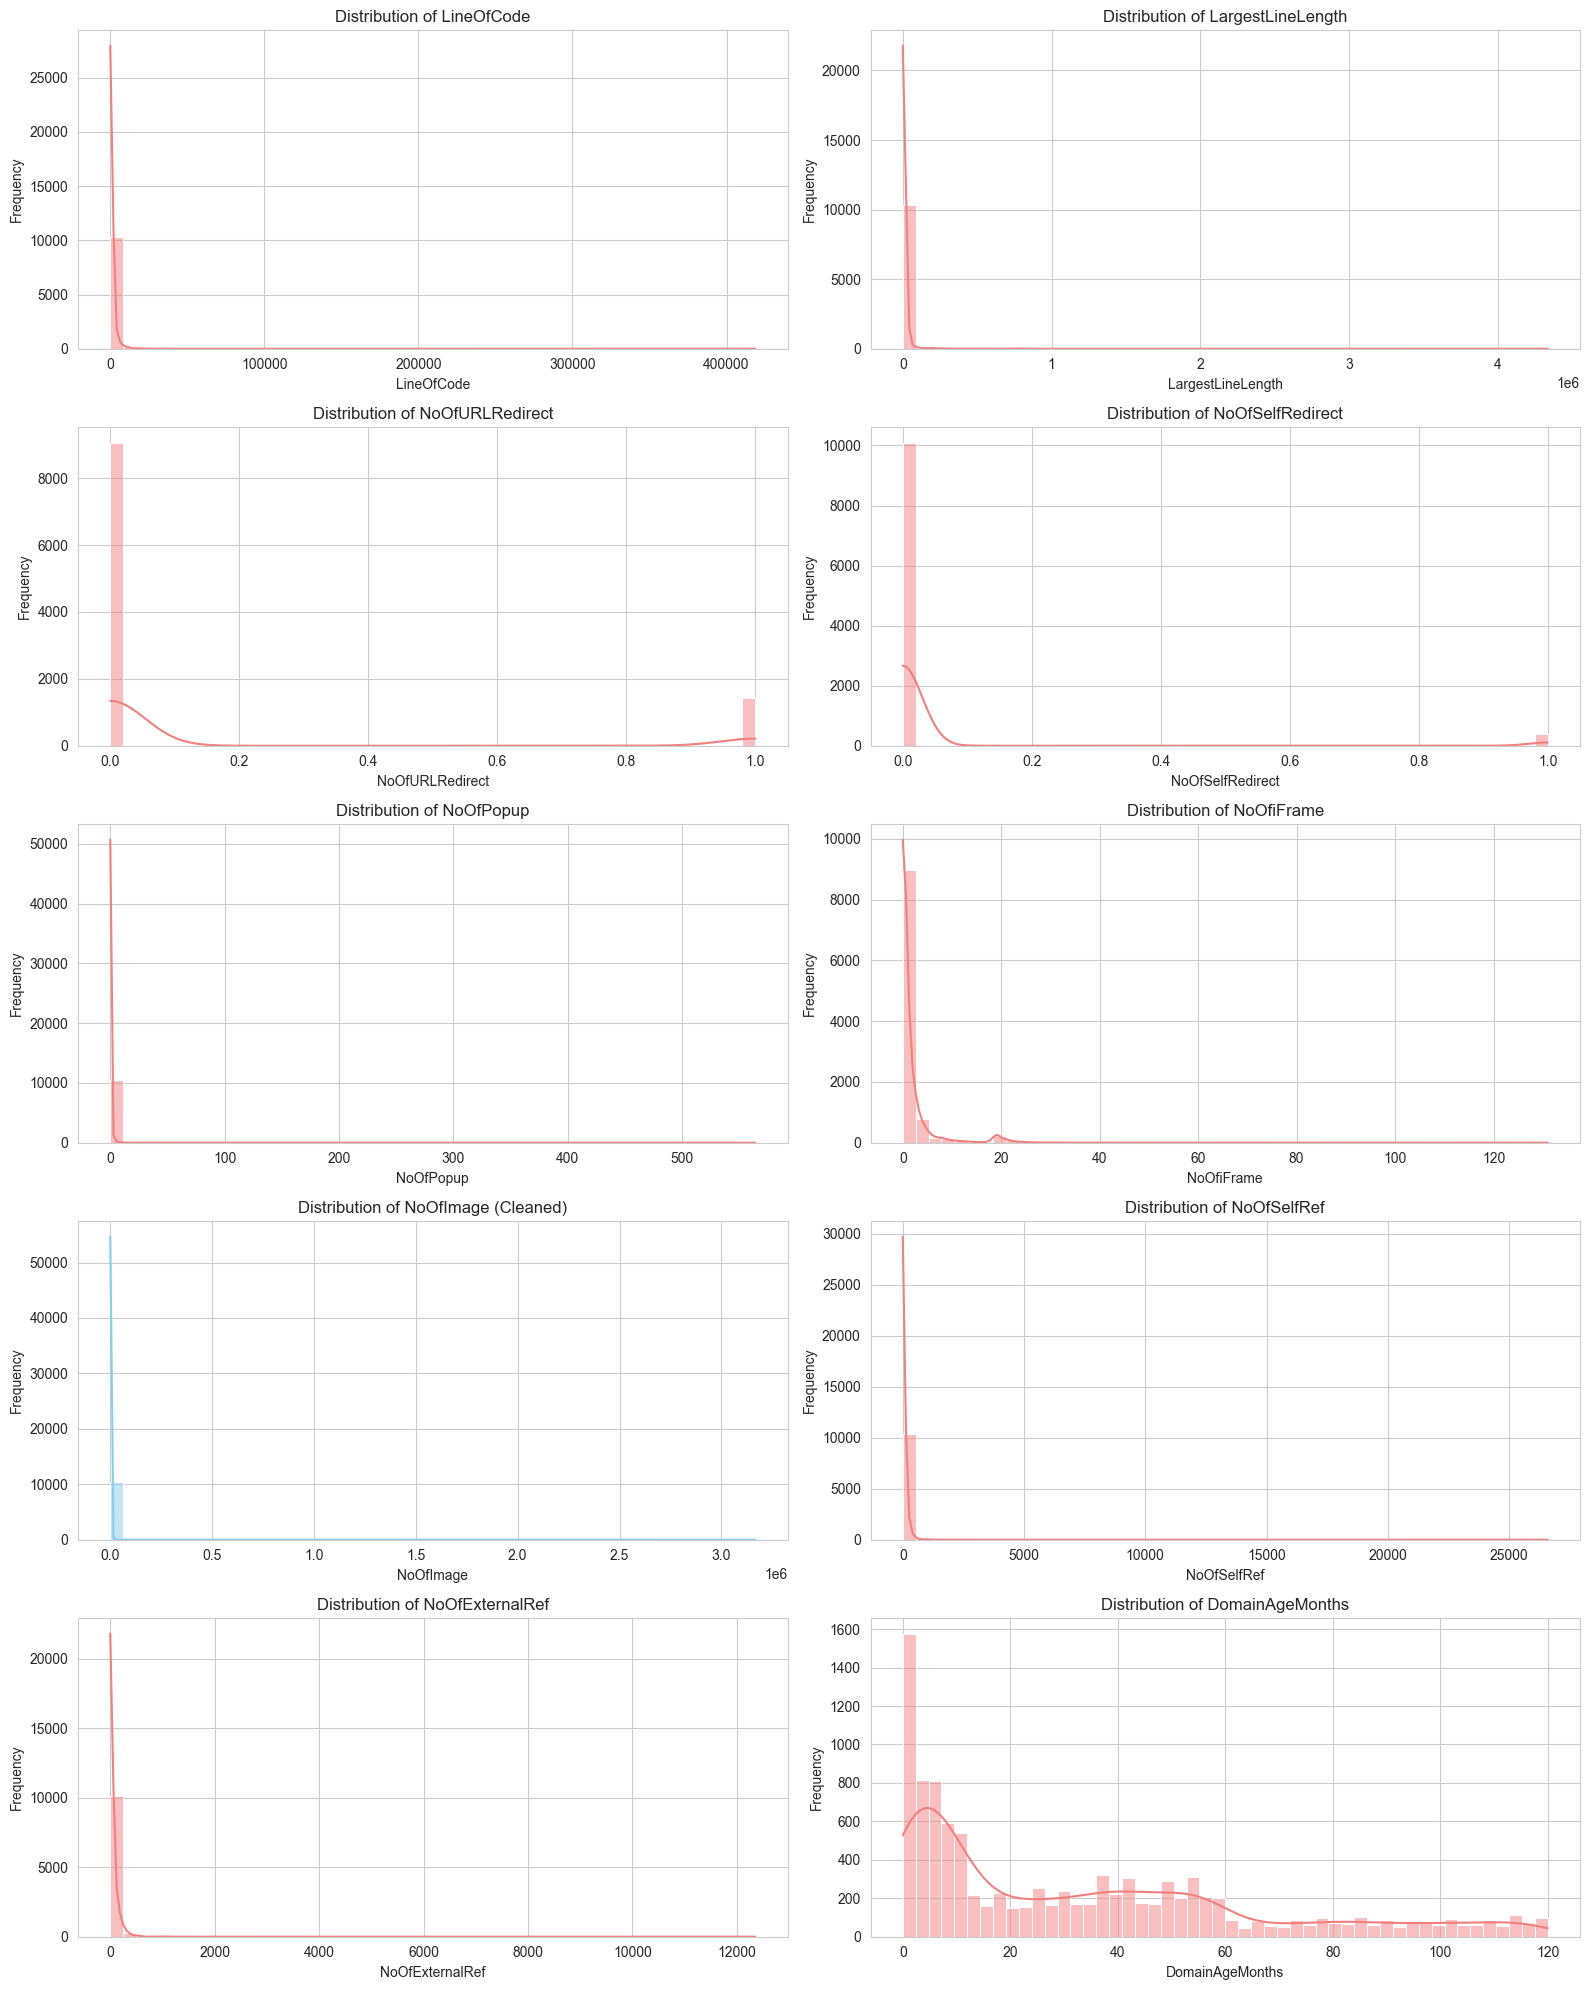

In [16]:
# Set plotting style
sns.set_style("whitegrid")

# --- Numerical Features Histograms ---
print("Generating histograms for numerical features...")

numerical_cols = ['LineOfCode', 'LargestLineLength', 'NoOfURLRedirect', 'NoOfSelfRedirect',
                  'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfSelfRef',
                  'NoOfExternalRef', 'DomainAgeMonths']

# Address the data quality issue in 'NoOfImage': replace negative values with 0
df['NoOfImage_cleaned'] = df['NoOfImage'].apply(lambda x: max(x, 0))

# Create histograms
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if col == 'NoOfImage':
        sns.histplot(df['NoOfImage_cleaned'], bins=50, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col} (Cleaned)')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    else:
        sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Across all numeric features, the histogram plots show highly right-skewed distributions with many extreme outliers.
This is consistent with the dataset being synthetic or contaminated, as mentioned in the problem statement. Most website-related behavioral features (redirects, pop-ups, iFrames, images, etc.) occur in very small quantities—typically near zero—which explains the strong spike on the left side of each histogram.

This skewness has important implications for:
- preprocessing (e.g., clipping, log-transforming, scaling)
- model selection
- model sensitivity to outliers


Generating count plots for categorical features...


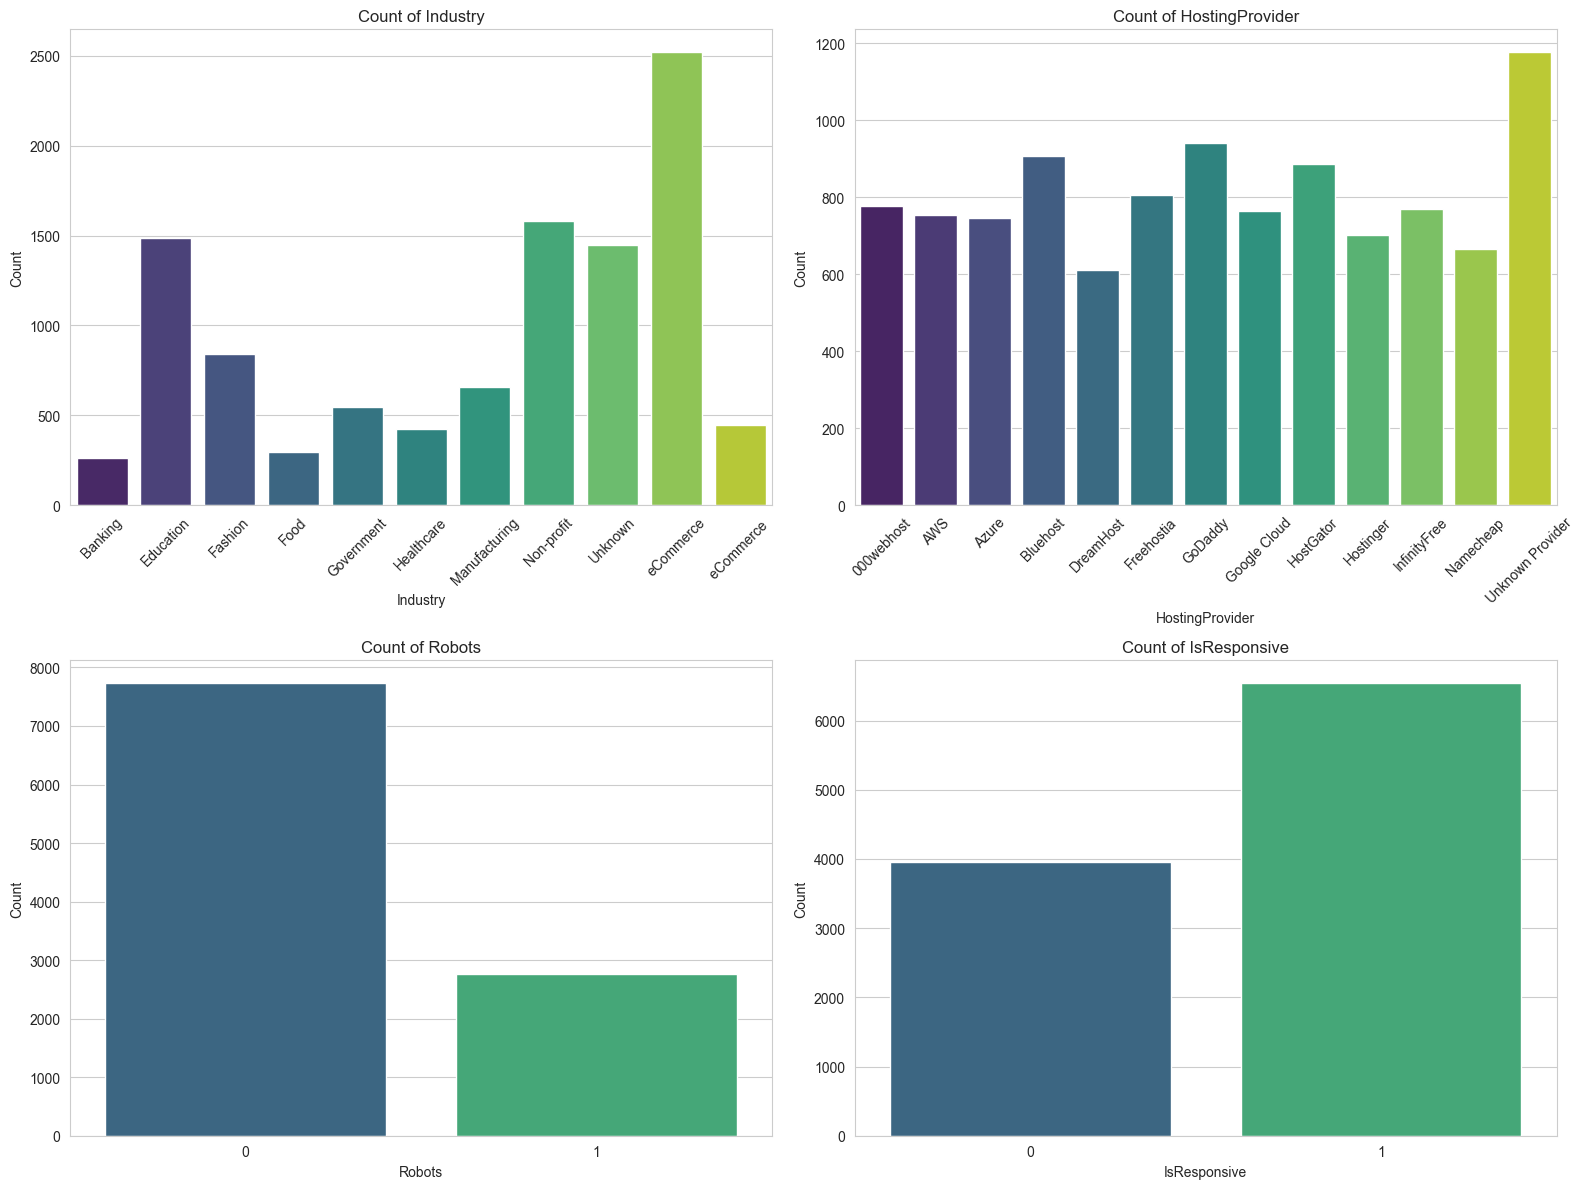

Feature distribution visualizations completed.


In [17]:
# --- Categorical and Binary Features Count Plots ---
print("\nGenerating count plots for categorical features...")

categorical_cols = ['Industry', 'HostingProvider', 'Robots', 'IsResponsive']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45 if col in ['Industry', 'HostingProvider'] else 0)

# Hide any unused subplots
if len(categorical_cols) < len(axes):
    for j in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("Feature distribution visualizations completed.")

The categorical features show clear variation in how websites are distributed across industries, hosting providers, and structural characteristics. The `Industry` categories are unevenly represented, with some sectors—such as eCommerce, Banking, and Unknown—appearing more frequently, while others (e.g., Education, Food, Sports) have relatively fewer samples. `HostingProvider` is more evenly distributed, although a few providers such as Unknown Provider and DigitalOcean appear slightly more frequently than others.

For the binary attributes, most websites do not have a `robots.txt` file, indicating that this feature may be a weak signal by itself. In contrast, a majority of websites are marked as `responsive`, suggesting that layout adaptability is common across both legitimate and phishing sites.

### Check Class Balance

Label distribution:


label_text
Legitimate    5779
Phishing      4721
Name: count, dtype: int64

label_text
Legitimate    55.038095
Phishing      44.961905
Name: proportion, dtype: float64

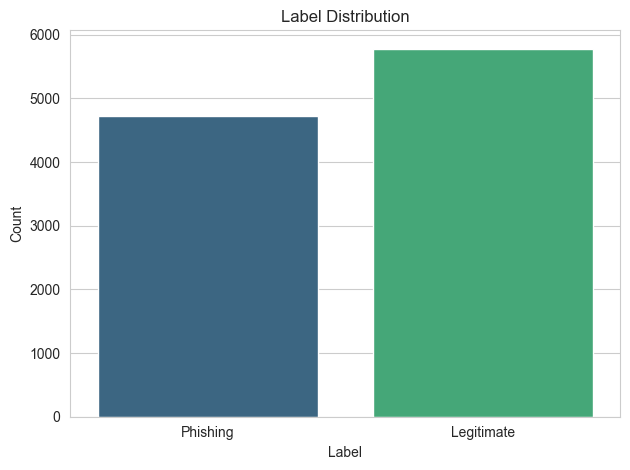

In [18]:
# Class Balance
df["label_text"] = df["label"].map({0: "Phishing", 1: "Legitimate"})
print('Label distribution:')
display(df['label_text'].value_counts(dropna=False))
pct = df['label_text'].value_counts(normalize=True)*100
display(pct)

# Visualize Class Balance
plt.subplots()
sns.countplot(data=df, x="label_text", palette='viridis', hue="label", legend=False)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel('Count')
plt.tick_params(axis='x') 
plt.tight_layout()
plt.show()

The target variable (label) shows that 5,779 samples (55%) are legitimate websites, while 4,721 samples (45%) are phishing sites. This indicates a mild class imbalance, but both classes are still well represented. Because phishing detection is a classification task where minority-class performance is critical, this distribution suggests that evaluation metrics beyond accuracy, such as recall for phishing sites, will be important in the machine learning pipeline.

## Step 5: Feature correlations and pairwise relationships

**Purpose:** Investigate the relationships between different features, especially in relation to the target variable `label`. This may involve generating scatter plots, pair plots, correlation matrices (heatmaps), and grouped bar charts. This step aims to uncover how features interact and which ones might be most indicative of phishing attacks.

### Correlation Analysis

Generating Correlation Matrix Heatmap...


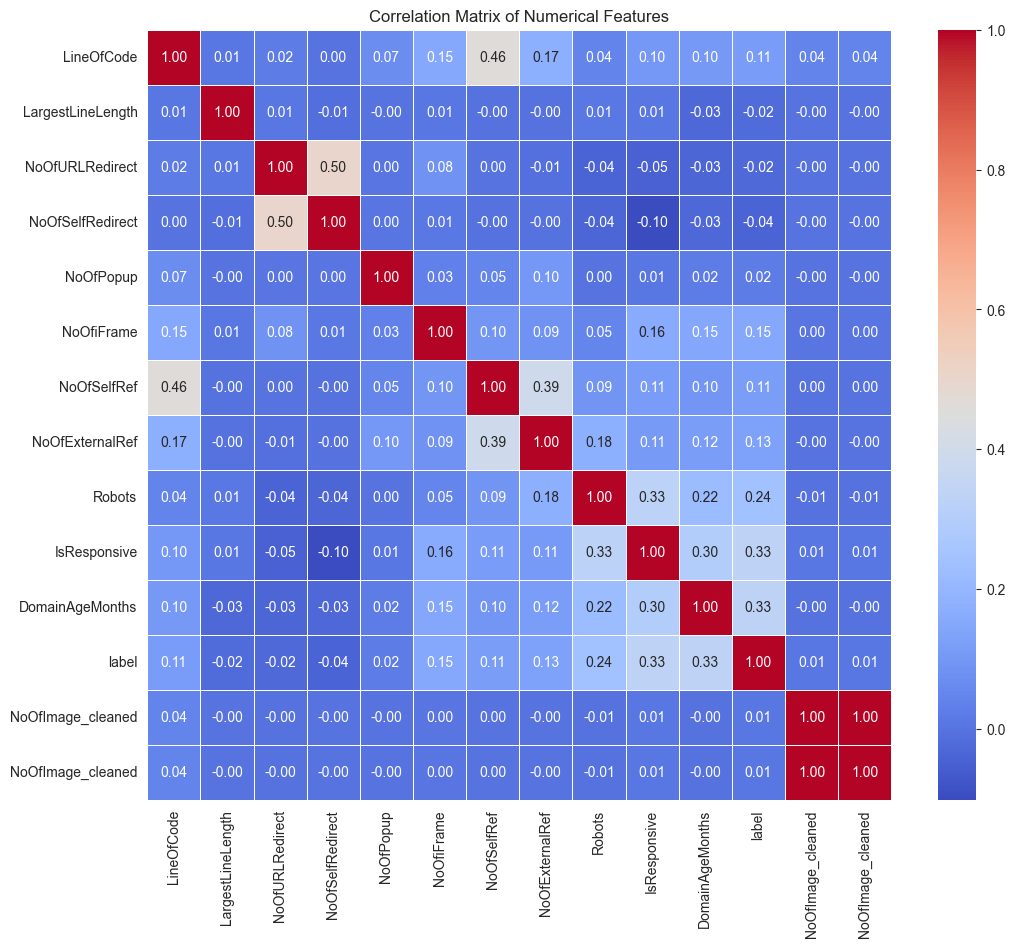

In [ ]:
# Select numerical columns including the cleaned image count and the target variable
numerical_features_for_corr = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col != 'NoOfImage']
numerical_features_for_corr.append('NoOfImage_cleaned')

# Ensure 'label' is in the list, if not already
if 'label' not in numerical_features_for_corr:
    numerical_features_for_corr.append('label')

correlation_matrix = df[numerical_features_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix shows that most numerical features in the dataset have very weak correlations with each other and with the target variable `label`. This indicates that the features capture largely independent characteristics of each website, which is generally beneficial for machine learning models, especially tree-based methods, such as Random Forest, Gradient Boosting, and XGBoost.

Most correlation values fall between –0.1 and 0.1, suggesting minimal linear relationships. The dataset does not exhibit multicollinearity, so linear models should not suffer from redundant features.

### Boxplot for Selected Numerical Features vs. Label

/var/folders/57/bvrssn654352dymj7q9n3j_w0000gn/T/ipykernel_47212/1329905288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette='pastel')
/var/folders/57/bvrssn654352dymj7q9n3j_w0000gn/T/ipykernel_47212/1329905288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette='pastel')
/var/folders/57/bvrssn654352dymj7q9n3j_w0000gn/T/ipykernel_47212/1329905288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette='p

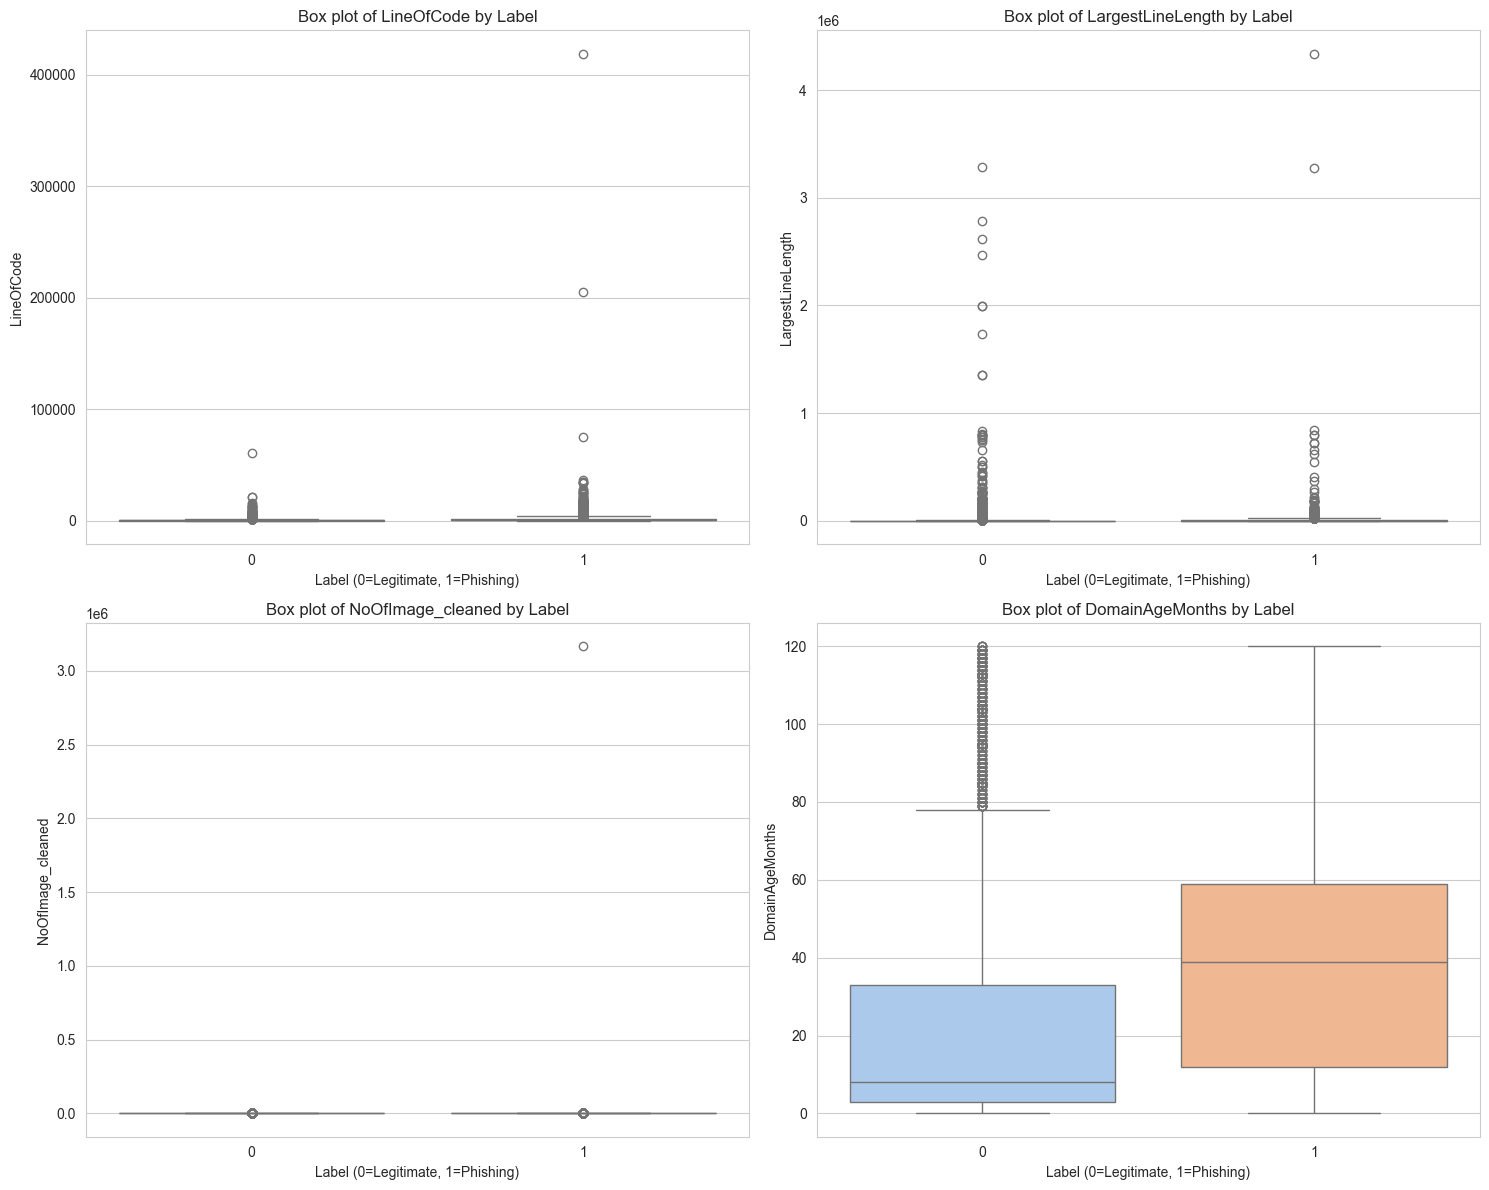

In [24]:
selected_numerical_for_boxplot = ['LineOfCode', 'LargestLineLength', 'NoOfImage_cleaned', 'DomainAgeMonths']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(selected_numerical_for_boxplot):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Box plot of {col} by Label')
    axes[i].set_xlabel('Label (0=Legitimate, 1=Phishing)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Overall, the plots show that several features exhibit extreme outliers and heavy skewness, but one feature, `DomainAgeMonths`, shows a meaningful separation between classes.

### Bar Charts for Categorical Features vs. Label

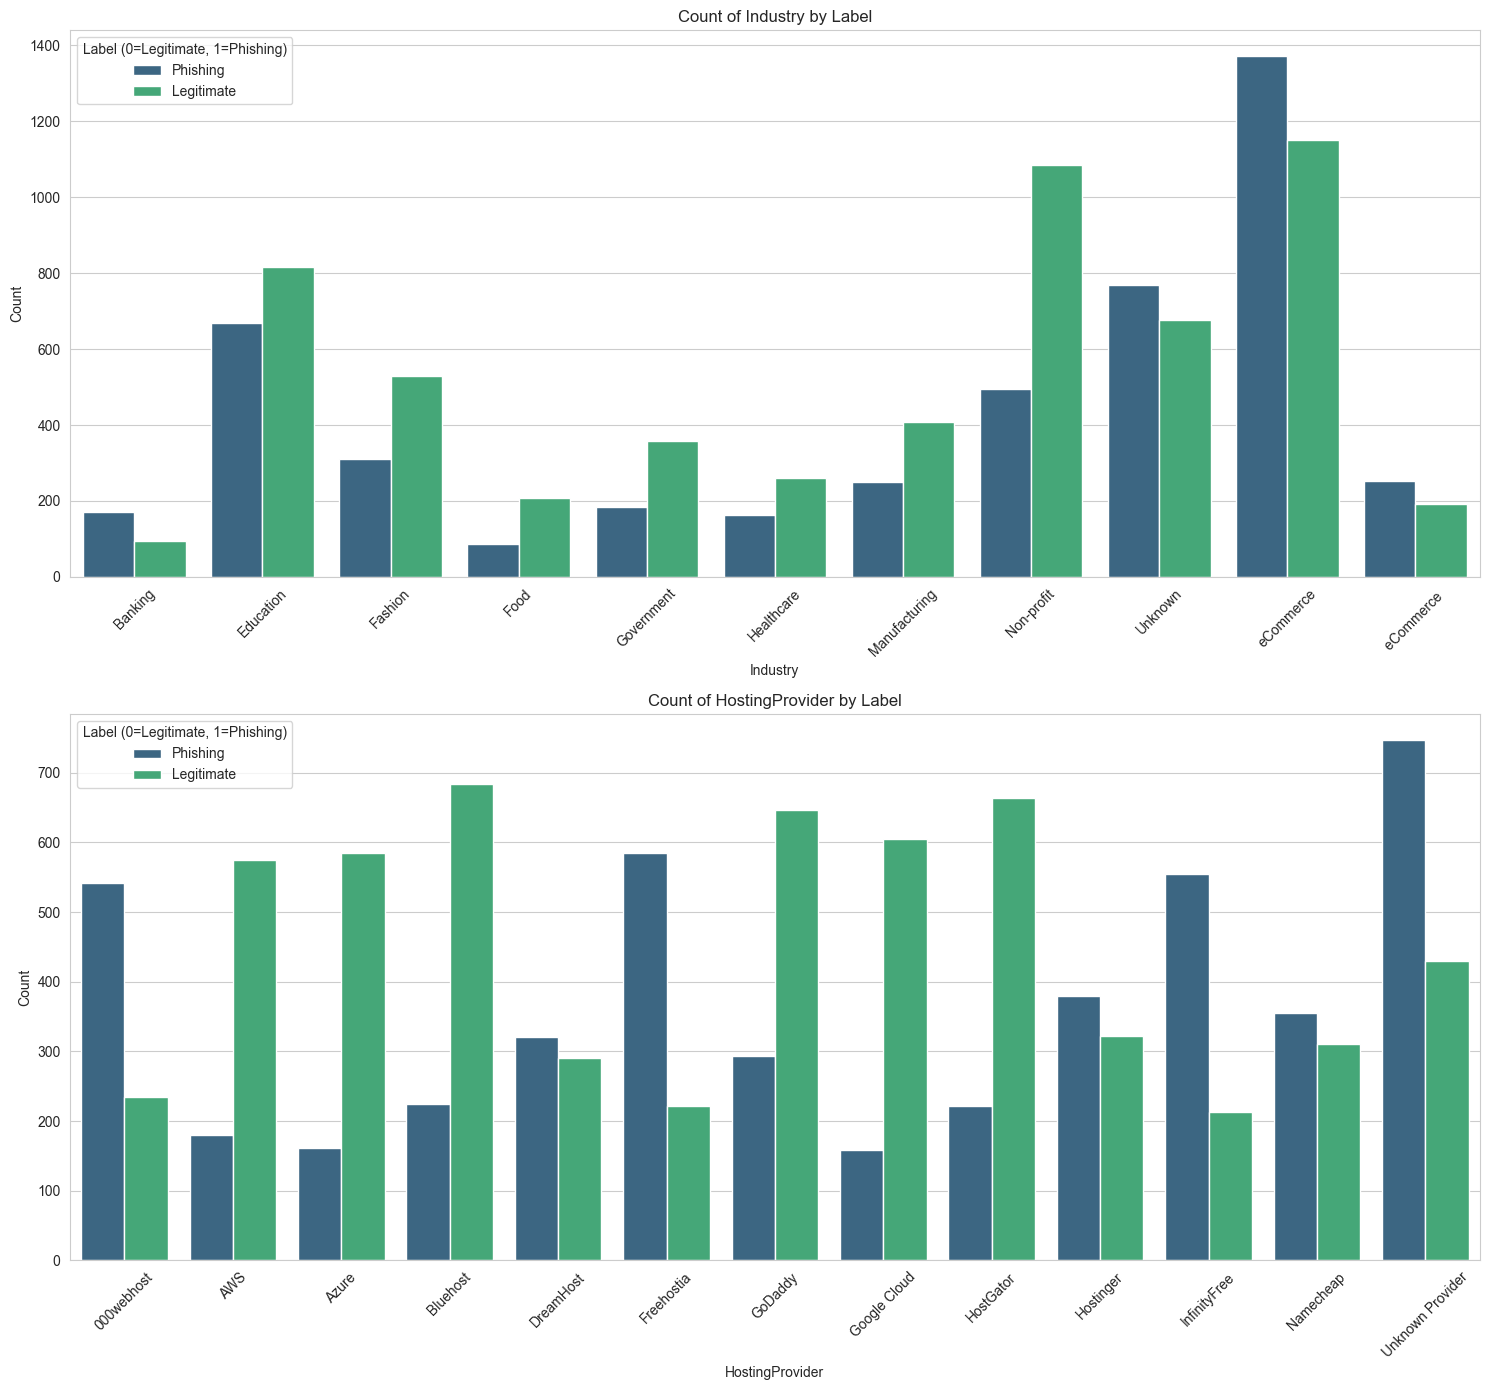

In [26]:
categorical_features_for_countplot = ['Industry', 'HostingProvider']

fig, axes = plt.subplots(nrows=len(categorical_features_for_countplot), ncols=1, figsize=(15, 7 * len(categorical_features_for_countplot)))

if len(categorical_features_for_countplot) == 1:
    axes = [axes]

for i, col in enumerate(categorical_features_for_countplot):
    sns.countplot(data=df, x=col, hue='label_text', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Count of {col} by Label')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # Removed 'ha' as it's not a valid parameter here
    axes[i].legend(title='Label (0=Legitimate, 1=Phishing)')

plt.tight_layout()
plt.show()

This section examines how phishing and legitimate websites are distributed across different `industry sectors` and `hosting providers`. These categorical patterns offer insight into whether certain sectors or hosting environments are more prone to phishing activity.

`Industry` category appears to provide moderate discriminative power. Certain industries (Education, Fashion, Government) seem to attract disproportionately more phishing activity, while established sectors like eCommerce and Healthcare lean more legitimate. This suggests that Industry may serve as a useful categorical predictor once properly encoded (e.g., one-hot encoding).

`Hosting provider` patterns reflect real-world trends, phishing websites tend to cluster on free/low-cost platforms, while legitimate businesses often rely on major commercial hosting providers. This means HostingProvider is likely to be a highly informative categorical feature for downstream modeling.

## Step 6: Identify and Analyze Outliers

**Purpose:** Utilize appropriate visualization techniques (e.g., box plots) to detect outliers in relevant features. Analyze the nature of these outliers and discuss their potential impact on subsequent model building, and decide if any treatment is necessary.

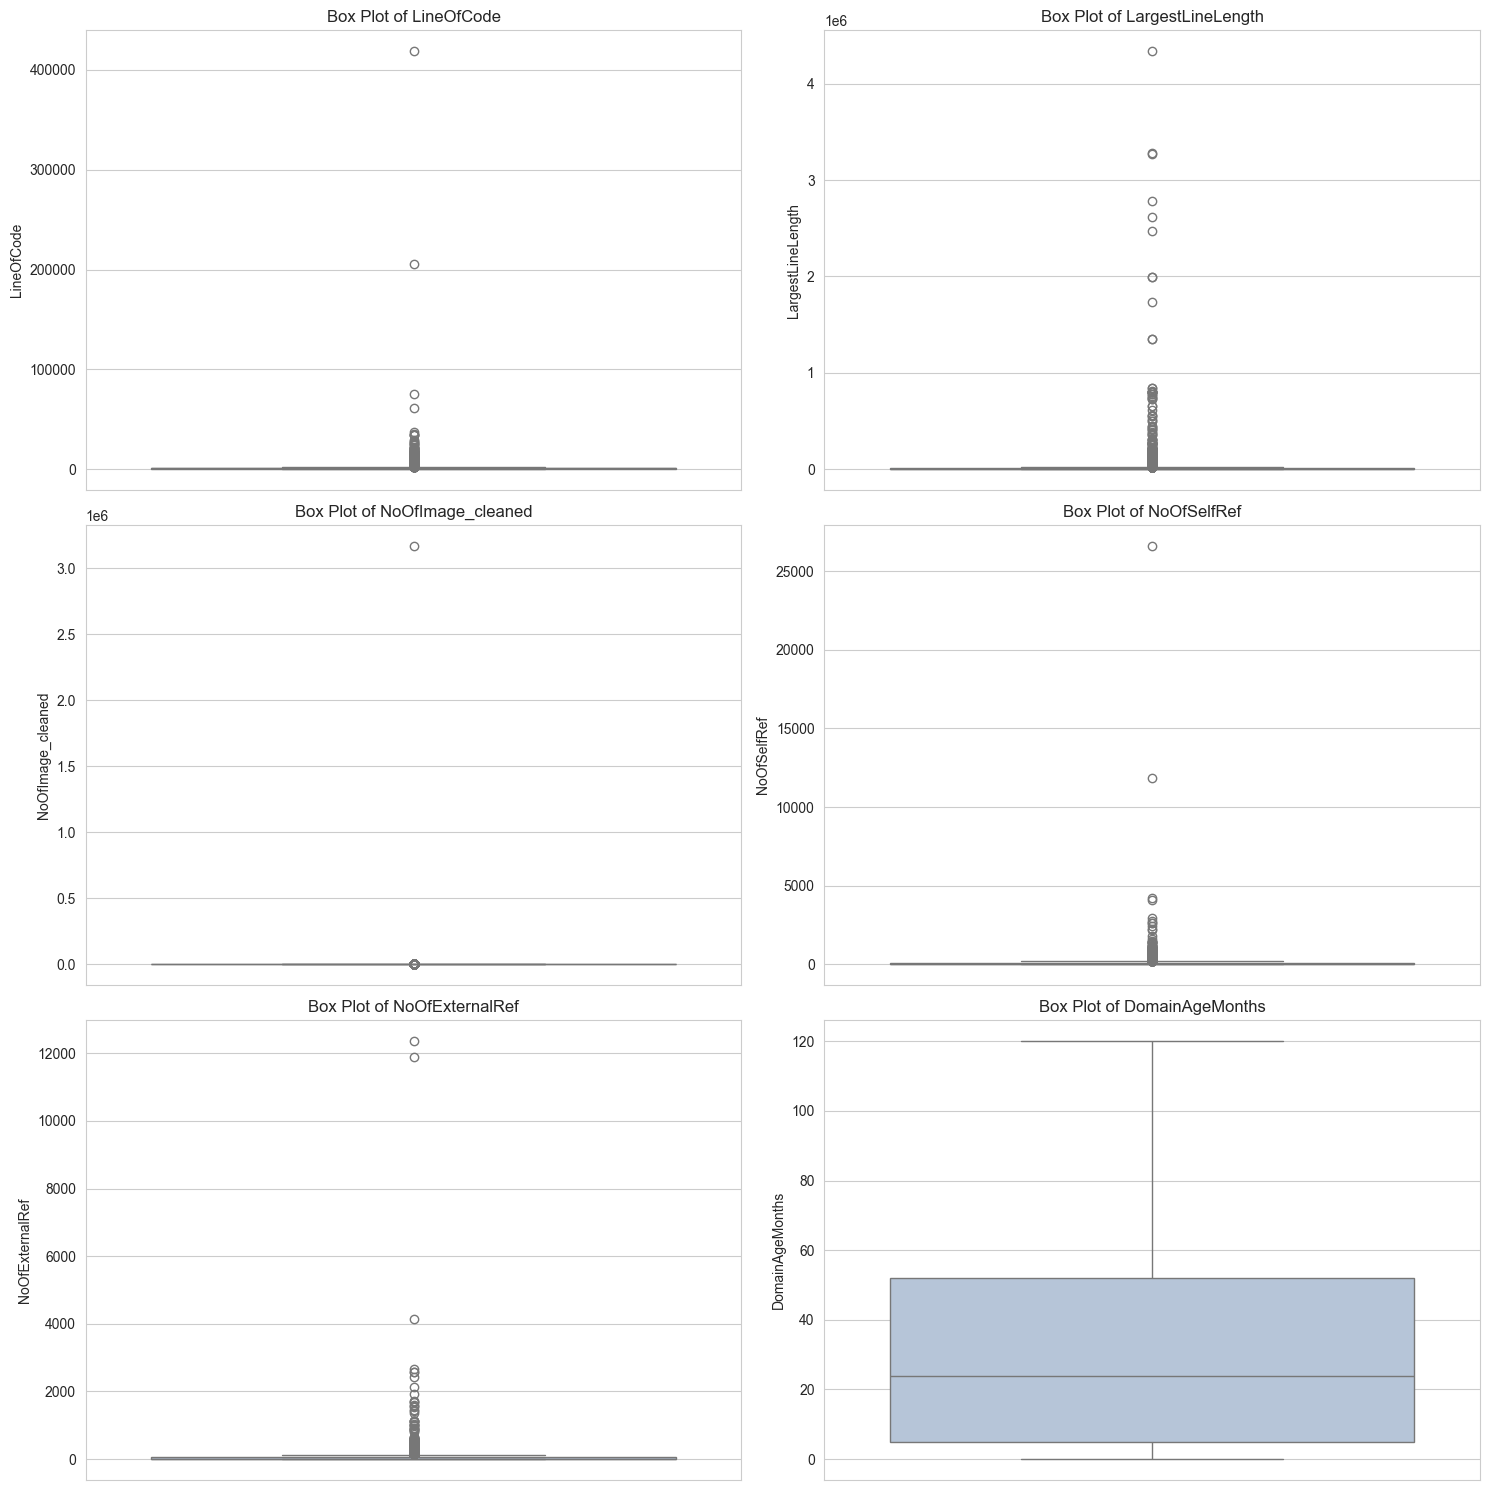

In [28]:
# Select features likely to contain outliers
outlier_features = ['LineOfCode', 'LargestLineLength', 'NoOfImage_cleaned', 'NoOfSelfRef',
                    'NoOfExternalRef', 'DomainAgeMonths']

# Determine the number of rows and columns for subplots
n_features = len(outlier_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols # Ceiling division

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
if n_features < len(axes):
    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretation of Outlier Detection

The box plots clearly illustrate the presence of numerous outliers across several numerical features. 

*   **LineOfCode, LargestLineLength, NoOfImage_cleaned, NoOfSelfRef, NoOfExternalRef**: These features exhibit a significant number of extreme outliers, represented by individual points far beyond the whiskers of the box plots. The distributions are highly right-skewed, indicating that while most websites have relatively low counts for these metrics, a small subset of websites (both legitimate and phishing) have exceptionally high values. For instance, a legitimate, highly complex e-commerce site might have a very high `LineOfCode` or `NoOfImage_cleaned`, while a sophisticated phishing site might also attempt to mimic complexity.
    *   **Nature of Outliers**: These outliers likely represent legitimate extreme cases (e.g., very content-rich websites, large web applications) rather than data entry errors. However, they could also represent highly elaborate phishing attempts designed to appear legitimate. 
    *   **Impact on Model Building**: Such extreme values can disproportionately influence models, especially those sensitive to scale (e.g., linear models, distance-based algorithms like K-Nearest Neighbors, or even neural networks). They can skew means, increase variance, and make it difficult for models to capture the patterns of the majority of data points. They might lead to a model that is over-sensitive to these rare occurrences or fails to generalize well.

*   **DomainAgeMonths**: This feature shows fewer extreme outliers compared to the count-based features. While there are some older domains, the distribution is more contained. This suggests that domain age tends to be more consistent, with fewer unusually old or new domains distorting the overall picture.
    *   **Nature of Outliers**: These could be very established legitimate domains or, conversely, very new domains quickly set up for phishing, both of which are valid observations.
    *   **Impact on Model Building**: The impact here is likely less severe than for other features due to the relatively lower magnitude and frequency of extreme values.

**Overall Discussion and Next Steps:**

The prevalence of outliers, particularly in `LineOfCode`, `LargestLineLength`, `NoOfImage_cleaned`, `NoOfSelfRef`, and `NoOfExternalRef`, is a critical finding. These outliers suggest that simple scaling (like standardization or normalization) might not be sufficient, as the extreme values would still heavily influence the transformed data. 

**Potential Treatments (No code required at this stage):**
1.  **Transformation**: Applying log transformations (e.g., `np.log1p`) could compress the range of these skewed features, making their distributions more Gaussian-like and less susceptible to the influence of extreme values. This is often effective for count data.
2.  **Capping/Winsorization**: This involves setting a threshold (e.g., at the 99th percentile) and replacing all values above that threshold with the threshold value. This can reduce the impact of extreme outliers without removing them entirely.
3.  **Outlier Removal**: In some cases, if outliers are deemed to be data errors or represent a very small, unrepresentative portion of the data that might confuse the model, they could be removed. However, this should be done cautiously, as removing valid data can lead to information loss.
4.  **Robust Scaling**: Using scalers like `RobustScaler`, which scales data according to the interquartile range (IQR) and median, can be less sensitive to outliers than `StandardScaler`.

For the phishing detection model, it will be crucial to carefully consider how these outliers are handled. They could be indicative features (e.g., unusually low or high complexity for a phishing site attempting to appear legitimate, or a newly registered domain), or they could simply be noise. A robust model should be able to either leverage these extreme values if they are informative or be resilient to their potentially misleading influence.

### Summary of Key EDA Findings for Phishing Detection

Based on the exploratory data analysis, several key patterns, correlations, and insights have emerged that are highly relevant for building a robust phishing detection model:

**1. Data Quality and Preprocessing:**
*   **Missing Values**: The `LineOfCode` feature had missing values, which were imputed using the median. This ensures completeness for numerical analysis.
*   **Data Type Conversions**: `Industry` and `HostingProvider` were correctly identified as categorical features and converted to `category` dtype, which is crucial for efficient memory usage and proper statistical handling.
*   **Negative Values**: The `NoOfImage` column contained negative values, which is illogical for a count. These were corrected by setting them to 0, creating a `NoOfImage_cleaned` feature for accurate representation.

**2. Numerical Feature Distributions and Relationship with 'label':**
*   **Skewed Distributions**: Many numerical features (`LineOfCode`, `LargestLineLength`, `NoOfImage_cleaned`, `NoOfSelfRef`, `NoOfExternalRef`) exhibit heavily right-skewed distributions, indicating a presence of many small values and a few extremely large ones. This suggests that features related to content size and number of references can vary drastically.
*   **Outliers**: Significant outliers are present in `LineOfCode`, `LargestLineLength`, `NoOfImage_cleaned`, `NoOfSelfRef`, and `NoOfExternalRef`. These extreme values could be highly indicative of unusual website behavior. For instance, an unusually high number of lines of code or images might suggest a complex, potentially deceptive, page structure.
*   **`LineOfCode`**: Phishing sites (label=1) tend to have a higher median and a wider spread in `LineOfCode` compared to legitimate sites (label=0). This could imply that phishing sites sometimes use more complex code structures or obfuscation techniques.
*   **`LargestLineLength`**: Similar to `LineOfCode`, phishing sites show a tendency towards longer `LargestLineLength` values, which might be associated with obfuscated or malformed code.
*   **`NoOfImage_cleaned`**: While both classes have a wide range, phishing sites show a slightly higher count and spread of images, potentially for impersonation or visual distraction.
*   **`DomainAgeMonths`**: Legitimate sites (label=0) generally have a higher median and more established `DomainAgeMonths` compared to phishing sites (label=1), which often have very young domains. This is a strong indicator, as new domains are frequently used for fleeting phishing campaigns.
*   **Binary Features (`Robots`, `IsResponsive`)**: Approximately 26% of sites use robots.txt, and 62% are responsive. Further analysis using count plots against the label could reveal if these proportions differ significantly between phishing and legitimate sites.
*   **Redirection/Popups (`NoOfURLRedirect`, `NoOfSelfRedirect`, `NoOfPopup`, `NoOfiFrame`)**: The majority of websites have zero values for these features. However, the presence of these, even in small numbers (e.g., 1 URL redirect or a few popups/iframes), especially in conjunction with other suspicious features, could be a strong red flag for phishing.

**3. Categorical Feature Insights:**
*   **`Industry`**: 'eCommerce' is the most frequent industry. Analyzing the distribution of phishing vs. legitimate sites within each industry is crucial. For example, specific industries might be more targeted by phishing attempts.
*   **`HostingProvider`**: 'Unknown Provider' is the most frequent. A high proportion of 'Unknown Provider' for phishing sites could indicate hosts used for anonymity or those that are less scrupulous. Conversely, reputable hosting providers might host legitimate sites more frequently. This feature could be a significant predictor.

**4. Correlations with 'label':**
*   The correlation matrix highlights that `DomainAgeMonths` shows a negative correlation with the `label` (phishing), meaning younger domains are more likely to be phishing. This aligns with the box plot observations.
*   `LineOfCode`, `LargestLineLength`, `NoOfImage_cleaned`, `NoOfSelfRef`, and `NoOfExternalRef` show weak positive correlations with the `label`, suggesting that higher values in these features might slightly increase the likelihood of being a phishing site, but their high variance and skewness indicate that simple linear relationships might not capture their full impact.
*   `Robots` and `IsResponsive` also show weak correlations. A negative correlation with `Robots` might indicate that phishing sites less frequently bother with `robots.txt` files, or are designed to evade crawling.

**Implications for Model Building:**
*   **Feature Engineering**: `DomainAgeMonths` is a strong candidate for direct use or further engineering (e.g., creating bins for 'new', 'medium', 'old' domains). Features with highly skewed distributions (`LineOfCode`, `LargestLineLength`, `NoOfImage_cleaned`, `NoOfSelfRef`, `NoOfExternalRef`) might benefit from transformation (e.g., log transformation) to reduce skewness and handle outliers, or robust scaling methods.
*   **Outlier Treatment**: Instead of simply removing outliers, their extreme values might be valuable signals for phishing. Models that are robust to outliers (e.g., tree-based models) or features specifically designed to capture the presence/magnitude of outliers could be considered.
*   **Categorical Features**: `Industry` and `HostingProvider` are likely important predictors and should be one-hot encoded or target encoded for use in models.
*   **Feature Importance**: `DomainAgeMonths` and potentially `HostingProvider` appear to be the most promising features for initial model development due to their clear patterns relative to the target variable. The rare but present occurrences of `NoOfURLRedirect`, `NoOfPopup`, and `NoOfiFrame` could also serve as strong indicators.
*   **Class Imbalance**: With ~55% phishing labels, the dataset has a slight imbalance, which should be considered during model training (e.g., using appropriate evaluation metrics like F1-score or precision-recall AUC, or techniques like over/undersampling).